# Mini-Projet - Prétraitement des données pour le Machine Learning
**Jeu de données :** Breast Cancer Wisconsin + corpus TF-IDF  
**Objectif :** Comparer StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler sur une chaîne de classification supervisée.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from scipy.sparse import issparse

print('Imports OK')

Imports OK


## II - Transformations de base

In [2]:
# Standardisation et vérification numérique


# Matrice d'entraînement : 3 observations, 2 caractéristiques
X_train = np.array([[1.0, 2.0],
                    [3.0, 4.0],
                    [5.0, 6.0]])

scaler_std = StandardScaler()

# fit_transform = calcule mu et sigma sur X_train, puis applique la transformation
X_scaled = scaler_std.fit_transform(X_train)

print('=== Vérification StandardScaler ===')
print('X original :\n', X_train)
print('X standardisé :\n', X_scaled)
print('Moyenne par colonne (attendu : [0. 0.]) :', X_scaled.mean(axis=0).round(10))
print('Variance par colonne (attendu : [1. 1.]) :', X_scaled.var(axis=0).round(10))

print('\n=== Attributs internes du StandardScaler ===')
print('mean_  (moyenne apprise)   :', scaler_std.mean_)
print('scale_ (ecart-type appris) :', scaler_std.scale_)
print('var_   (variance apprise)  :', scaler_std.var_)

print('\n=== Attributs internes du MinMaxScaler ===')
mms = MinMaxScaler().fit(X_train)
print('min_   :', mms.min_)
print('scale_ :', mms.scale_)

=== Vérification StandardScaler ===
X original :
 [[1. 2.]
 [3. 4.]
 [5. 6.]]
X standardisé :
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]
Moyenne par colonne (attendu : [0. 0.]) : [0. 0.]
Variance par colonne (attendu : [1. 1.]) : [1. 1.]

=== Attributs internes du StandardScaler ===
mean_  (moyenne apprise)   : [3. 4.]
scale_ (ecart-type appris) : [1.63299316 1.63299316]
var_   (variance apprise)  : [2.66666667 2.66666667]

=== Attributs internes du MinMaxScaler ===
min_   : [-0.25 -0.5 ]
scale_ : [0.25 0.25]


In [3]:
# Application sur X_test : fit vs transform
X_test = np.array([[2.0, 3.0]])

X_test_scaled = scaler_std.transform(X_test)
print('X_test original      :', X_test)
print('X_test standardisé   :', X_test_scaled)
print('(utilise mu et sigma calculés sur X_train, pas sur X_test)')

print()

X_test_wrong = StandardScaler().fit_transform(X_test)
print('X_test (mauvaise pratique, fit_transform) :', X_test_wrong)
print('=> Les deux résultats sont différents : la mauvaise pratique biaise le modèle')

X_test original      : [[2. 3.]]
X_test standardisé   : [[-0.61237244 -0.61237244]]
(utilise mu et sigma calculés sur X_train, pas sur X_test)

X_test (mauvaise pratique, fit_transform) : [[0. 0.]]
=> Les deux résultats sont différents : la mauvaise pratique biaise le modèle


## III - Données creuses et TF-IDF

In [4]:
# Corpus TF-IDF, matrices sparse, scalers compatibles
corpus = [
    'le chat mange le poisson',
    'le chien court dans le parc',
    'la voiture roule sur la route',
    'le chat et le chien sont amis',
    'le poisson nage dans l eau',
    'la route traverse le parc',
]

vectorizer = TfidfVectorizer()
X_sparse = vectorizer.fit_transform(corpus)

print('=== Structure de la matrice TF-IDF ===')
print('Type        :', type(X_sparse))
print('Forme       :', X_sparse.shape)
densite = X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1]) * 100
print(f'Densité     : {densite:.2f}%  ({100-densite:.2f}% de zéros)')
print('Sparse ?    :', issparse(X_sparse))

print()

# Method 1 : MaxAbsScaler — préserve la parcimonie
scaler_abs = MaxAbsScaler()
X_maxabs = scaler_abs.fit_transform(X_sparse)
print('Après MaxAbsScaler              — sparse ?', issparse(X_maxabs))
print('Valeurs min/max :', X_maxabs.min(), '/', X_maxabs.max())

# Method 2 : StandardScaler sans centrage
scaler_nc = StandardScaler(with_mean=False)
X_std_nc = scaler_nc.fit_transform(X_sparse)
print('Après StandardScaler(no mean)   — sparse ?', issparse(X_std_nc))

=== Structure de la matrice TF-IDF ===
Type        : <class 'scipy.sparse._csr.csr_matrix'>
Forme       : (6, 19)
Densité     : 26.32%  (73.68% de zéros)
Sparse ?    : True

Après MaxAbsScaler              — sparse ? True
Valeurs min/max : 0.0 / 1.0
Après StandardScaler(no mean)   — sparse ? True


## IV - Étude expérimentale comparative

In [5]:
# 4 scénarios de scaling sur Breast Cancer
X, y = load_breast_cancer(return_X_y=True)
print(f'Jeu Breast Cancer : {X.shape[0]} observations, {X.shape[1]} caractéristiques')
print(f'Classes : {np.bincount(y)}  (0=maligne, 1=bénigne)')
print()

scenarios = {
    'S1 - Aucun scaling' : None,
    'S2 - StandardScaler': StandardScaler(),
    'S3 - MinMaxScaler'  : MinMaxScaler(),
    'S4 - RobustScaler'  : RobustScaler(),
}

results = {}

for name, scaler in scenarios.items():
    # Construction du pipeline
    steps = []
    if scaler is not None:
        steps.append(('scaler', scaler))
    steps.append(('model', LogisticRegression(max_iter=1000, random_state=42)))
    pipe = Pipeline(steps)

    # Validation croisée à 5 plis
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25}  mean={scores.mean():.4f}  std={scores.std():.4f}')

print()
print('=> Sans scaling, la LogisticRegression converge mal (écarts d\'échelle trop importants)')

Jeu Breast Cancer : 569 observations, 30 caractéristiques
Classes : [212 357]  (0=maligne, 1=bénigne)



/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentati

S1 - Aucun scaling         mean=0.9543  std=0.0128
S2 - StandardScaler        mean=0.9807  std=0.0065
S3 - MinMaxScaler          mean=0.9613  std=0.0042
S4 - RobustScaler          mean=0.9789  std=0.0089

=> Sans scaling, la LogisticRegression converge mal (écarts d'échelle trop importants)


## V - Injection d'outliers et analyse de robustesse

In [6]:
# Injection d'outliers et comparaison des scalers

X_out = X.copy()
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=20, replace=False)  # 20 observations aléatoires
X_out[idx, :3] *= 50

print('=== Effet des outliers sur les distributions (colonne 0) ===')
print(f'Sans outliers  — max col 0 : {X[:, 0].max():.2f}')
print(f'Avec outliers  — max col 0 : {X_out[:, 0].max():.2f}')
print()

results_out = {}

for name, scaler in scenarios.items():
    steps = []
    if scaler is not None:
        steps.append(('scaler', scaler))
    steps.append(('model', LogisticRegression(max_iter=1000, random_state=42)))
    pipe = Pipeline(steps)

    scores = cross_val_score(pipe, X_out, y, cv=5, scoring='accuracy')
    results_out[name] = scores
    print(f'{name:<25}  mean={scores.mean():.4f}  std={scores.std():.4f}')

print()
print('=> RobustScaler résiste le mieux car la médiane et l\'IQR ne sont pas affectés par les extrêmes')
print('=> MinMaxScaler s\'effondre car son max est absorbé par l\'outlier')

=== Effet des outliers sur les distributions (colonne 0) ===
Sans outliers  — max col 0 : 28.11
Avec outliers  — max col 0 : 1030.00



/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentati

S1 - Aucun scaling         mean=0.9420  std=0.0188
S2 - StandardScaler        mean=0.9807  std=0.0065
S3 - MinMaxScaler          mean=0.9561  std=0.0146
S4 - RobustScaler          mean=0.9772  std=0.0070

=> RobustScaler résiste le mieux car la médiane et l'IQR ne sont pas affectés par les extrêmes
=> MinMaxScaler s'effondre car son max est absorbé par l'outlier


## VI - Pipeline complet et validation croisée

In [7]:
# Pipeline complet avec StratifiedKFold

pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

# Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipe_final, X, y,
    cv=cv,
    scoring='accuracy',
    return_train_score=True
)

print('=== Résultats du pipeline final (StandardScaler + LogisticRegression) ===')
print(f'Accuracy TEST  : {cv_results["test_score"].mean():.4f}  +/-  {cv_results["test_score"].std():.4f}')
print(f'Accuracy TRAIN : {cv_results["train_score"].mean():.4f}  +/-  {cv_results["train_score"].std():.4f}')
print()
print('Scores par pli :', cv_results['test_score'].round(4))
print()

ecart = cv_results['train_score'].mean() - cv_results['test_score'].mean()
if ecart < 0.02:
    print('=> Écart train/test faible : pas de surapprentissage détecté')
else:
    print(f'=> Écart train/test = {ecart:.4f} : possible surapprentissage')

=== Résultats du pipeline final (StandardScaler + LogisticRegression) ===
Accuracy TEST  : 0.9737  +/-  0.0166
Accuracy TRAIN : 0.9881  +/-  0.0011

Scores par pli : [0.9737 0.9474 0.9649 0.9912 0.9912]

=> Écart train/test faible : pas de surapprentissage détecté


## VII - Visualisations

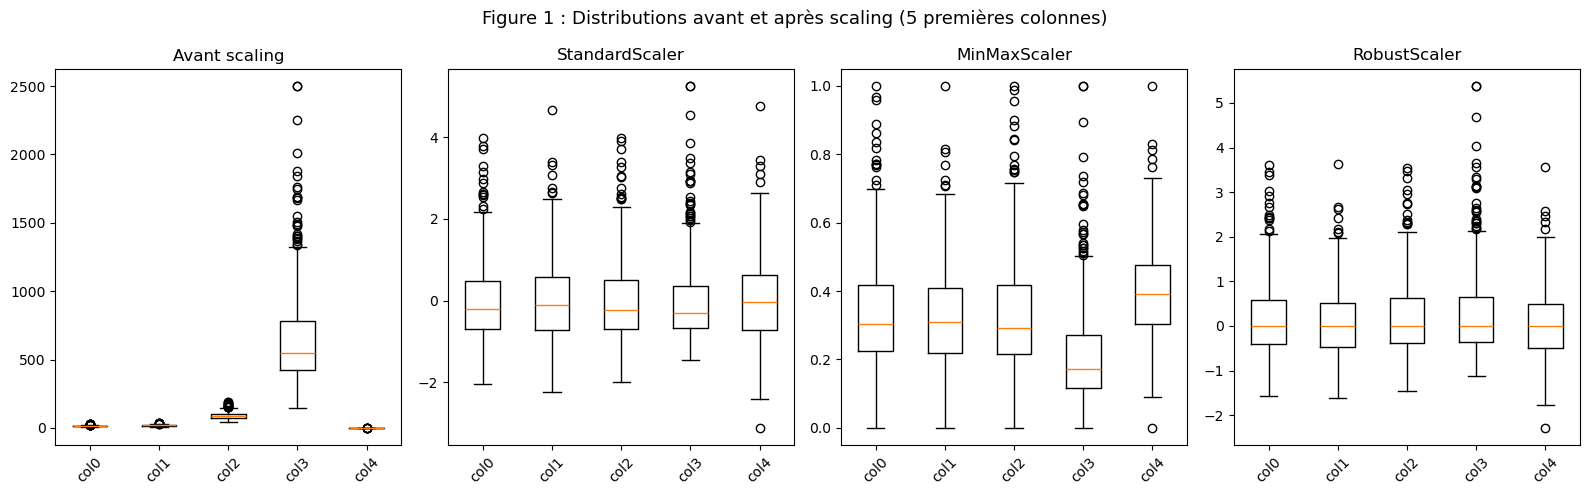

Figure 1 sauvegardée.


In [8]:
# Figure 1 : Boxplots before/after scaling

cols = [0, 1, 2, 3, 4]
labels = [f'col{i}' for i in cols]

scalers_viz = {
    'Avant scaling'  : X[:, cols],
    'StandardScaler' : StandardScaler().fit_transform(X)[:, cols],
    'MinMaxScaler'   : MinMaxScaler().fit_transform(X)[:, cols],
    'RobustScaler'   : RobustScaler().fit_transform(X)[:, cols],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Figure 1 : Distributions avant et après scaling (5 premières colonnes)', fontsize=13)

for ax, (title, data) in zip(axes, scalers_viz.items()):
    ax.boxplot(data, labels=labels)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig1_boxplot_scaling.png', dpi=150)
plt.show()
print('Figure 1 sauvegardée.')

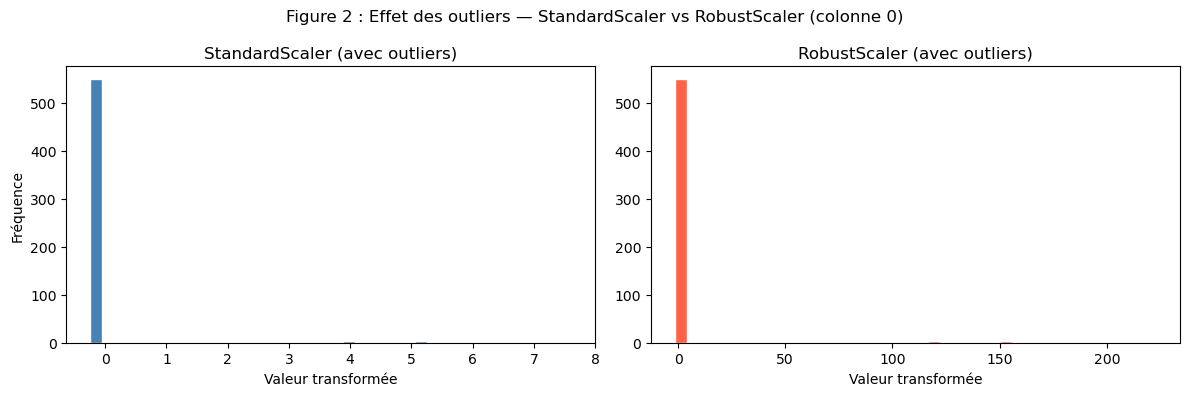

Figure 2 sauvegardée.


In [9]:
# Figure 2 : StandardScaler vs RobustScaler

col = 0 

X_out_std    = StandardScaler().fit_transform(X_out)[:, col]
X_out_robust = RobustScaler().fit_transform(X_out)[:, col]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Figure 2 : Effet des outliers — StandardScaler vs RobustScaler (colonne 0)', fontsize=12)

axes[0].hist(X_out_std, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('StandardScaler (avec outliers)')
axes[0].set_xlabel('Valeur transformée')
axes[0].set_ylabel('Fréquence')

axes[1].hist(X_out_robust, bins=40, color='tomato', edgecolor='white')
axes[1].set_title('RobustScaler (avec outliers)')
axes[1].set_xlabel('Valeur transformée')

plt.tight_layout()
plt.savefig('fig2_outliers_std_vs_robust.png', dpi=150)
plt.show()
print('Figure 2 sauvegardée.')

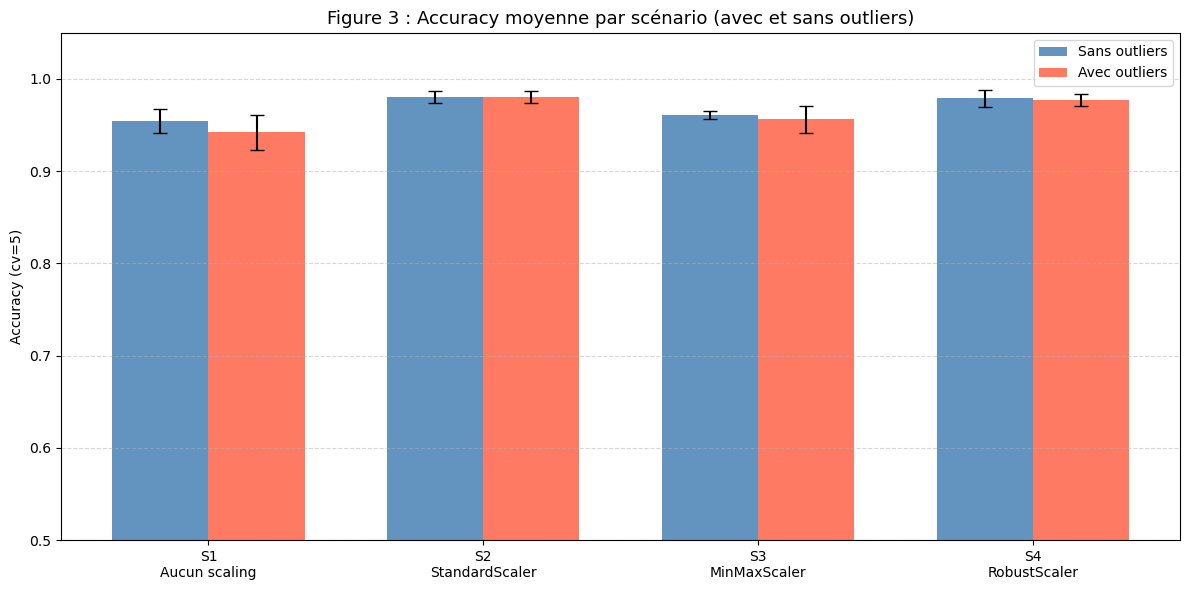

Figure 3 sauvegardée.


In [10]:
#Figure 3 : Accuracy Comparison

names   = list(results.keys())
means   = [results[n].mean()     for n in names]
stds    = [results[n].std()      for n in names]
means_o = [results_out[n].mean() for n in names]
stds_o  = [results_out[n].std()  for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, means,   width, yerr=stds,   capsize=5,
               label='Sans outliers', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, means_o, width, yerr=stds_o, capsize=5,
               label='Avec outliers', color='tomato',    alpha=0.85)

ax.set_title('Figure 3 : Accuracy moyenne par scénario (avec et sans outliers)', fontsize=13)
ax.set_ylabel('Accuracy (cv=5)')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' - ', '\n') for n in names])
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig3_comparaison_accuracy.png', dpi=150)
plt.show()
print('Figure 3 sauvegardée.')